## 1. Environment Setup

We pin library versions to keep results reproducible. We use `torchvision` for transforms because the Kaggle environment has a compatibility issue between `albumentations` and `numpy` at the time of writing.


In [1]:
!pip install -q timm==1.0.7 rasterio==1.3.10

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 25.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 53.2 MB/s eta 0:00:0000:01m00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.0 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
tobler 0.14.0 requires rasterio>=1.4, but you have rasterio 1.3.10 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you ha

In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import rasterio

from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
warnings.filterwarnings('ignore', category=UserWarning)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('GPU:', torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'none')

Device: cuda
GPU: Tesla T4


## 2. Reproducibility

We fix seeds across Python, NumPy, and PyTorch (CPU + GPU) and set cuDNN to deterministic mode so results can be reproduced exactly.


In [3]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f'Seed set to {SEED}')

Seed set to 42


## 3. Configuration

All paths and hyperparameters are defined here. If you're running this outside Kaggle, the only thing you should need to change is `DATA_ROOT`.


In [4]:
DATA_ROOT = Path('/kaggle/input/competitions/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared')
OUTPUT_DIR = Path('/kaggle/working')
FIG_DIR = OUTPUT_DIR / 'figures'
CKPT_DIR = OUTPUT_DIR / 'checkpoints'
FIG_DIR.mkdir(exist_ok=True, parents=True)
CKPT_DIR.mkdir(exist_ok=True, parents=True)

CLASS_TO_IDX = {'Health': 0, 'Rust': 1, 'Other': 2}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
CLASS_NAMES = ['Health', 'Rust', 'Other']
NUM_CLASSES = 3

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-4
WEIGHT_DECAY = 1e-4
N_FOLDS = 5
HS_BANDS = 125
HS_ENCODED_CH = 16

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

assert DATA_ROOT.exists(), f'DATA_ROOT does not exist: {DATA_ROOT}\nCheck the Input panel and adjust the path.'
print(f'Data root OK: {DATA_ROOT}')
print(f'Train RGB files: {len(list((DATA_ROOT / "train" / "RGB").iterdir()))}')
print(f'Val RGB files:   {len(list((DATA_ROOT / "val" / "RGB").iterdir()))}')

Data root OK: /kaggle/input/competitions/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared
Train RGB files: 600
Val RGB files:   300


## 4. Build Training Dataframe

Filenames follow the pattern `Health_hyper_42.png`. We parse the class label from the prefix and link each RGB file to its matching MS and HS files by sample ID.


In [5]:
def build_train_df():
    records = []
    rgb_dir = DATA_ROOT / 'train' / 'RGB'
    for fp in sorted(rgb_dir.iterdir()):
        cls_name = fp.stem.split('_')[0]
        sample_id = fp.stem.split('_')[-1]
        records.append({
            'sample_id': f'{cls_name}_{sample_id}',
            'rgb_path': str(fp),
            'ms_path':  str(DATA_ROOT / 'train' / 'MS' / f'{fp.stem}.tif'),
            'hs_path':  str(DATA_ROOT / 'train' / 'HS' / f'{fp.stem}.tif'),
            'label': CLASS_TO_IDX[cls_name],
            'class_name': cls_name,
        })
    return pd.DataFrame(records)

train_df = build_train_df()
print(f'Total training samples: {len(train_df)}')
print('Class balance:')
print(train_df['class_name'].value_counts())
train_df.head()

Total training samples: 600
Class balance:
class_name
Health    200
Other     200
Rust      200
Name: count, dtype: int64


,sample_id,rgb_path,ms_path,hs_path,label,class_name
0,Health_1,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,0,Health
1,Health_10,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,0,Health
2,Health_100,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,0,Health
3,Health_101,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,0,Health
4,Health_102,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,/kaggle/input/competitions/beyond-visible-spec...,0,Health


## 5. EDA — Sample Visualization

Looking at one sample per class across all three modalities. At 64×64, the RGB images make it quite hard to tell Health from Rust visually. The MS NIR band is more informative, and the HS patch — while lower resolution at 32×32 — carries 125 bands of spectral detail.


Health: RGB (64, 64, 3), MS (5, 64, 64), HS (125, 32, 32)
Rust: RGB (64, 64, 3), MS (5, 64, 64), HS (125, 32, 32)
Other: RGB (64, 64, 3), MS (5, 64, 64), HS (125, 32, 32)


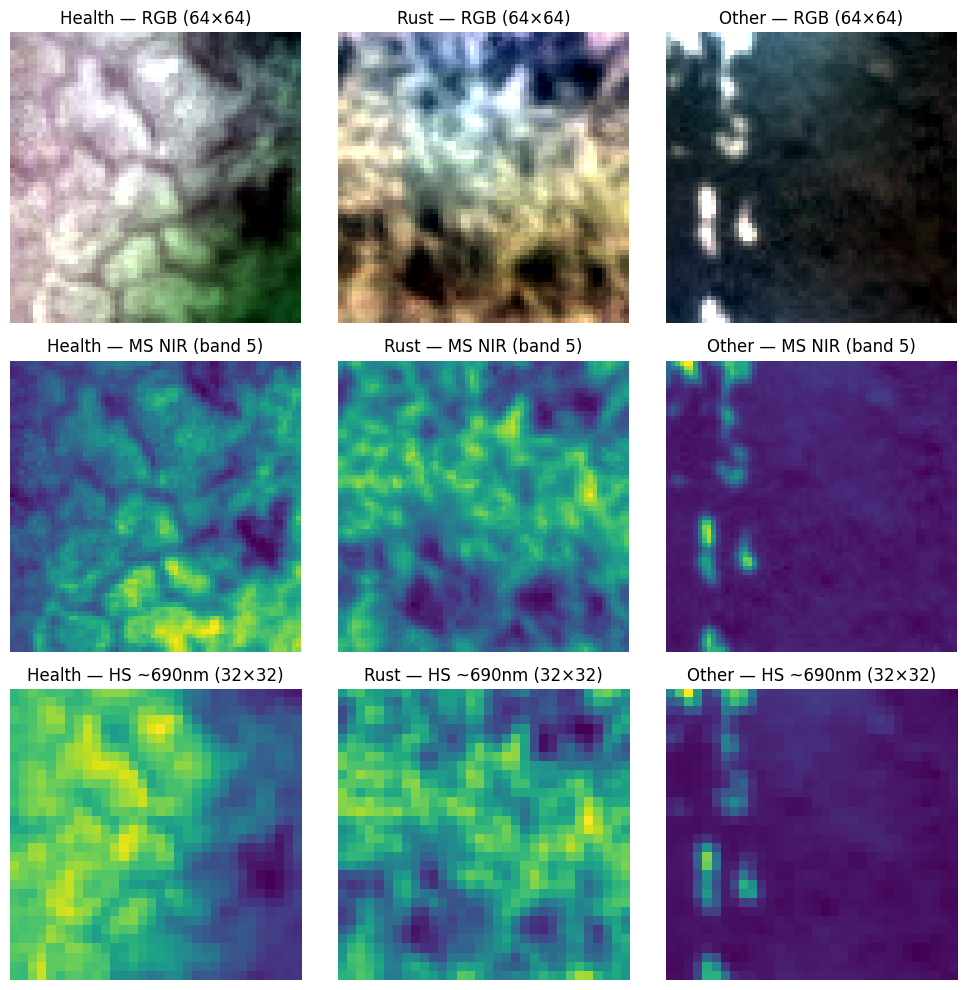

Saved: /kaggle/working/figures/fig1_samples_per_class.png


In [6]:
def load_rgb(path):
    return np.array(Image.open(path).convert('RGB'))

def load_tif(path):
    with rasterio.open(path) as src:
        return src.read()

samples = {}
for cls in CLASS_NAMES:
    row = train_df[train_df['class_name'] == cls].iloc[0]
    samples[cls] = {
        'rgb': load_rgb(row['rgb_path']),
        'ms':  load_tif(row['ms_path']),
        'hs':  load_tif(row['hs_path']),
    }
    print(f'{cls}: RGB {samples[cls]["rgb"].shape}, MS {samples[cls]["ms"].shape}, HS {samples[cls]["hs"].shape}')

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for col, cls in enumerate(CLASS_NAMES):
    s = samples[cls]
    axes[0, col].imshow(s['rgb'])
    axes[0, col].set_title(f'{cls} — RGB (64×64)')
    axes[1, col].imshow(s['ms'][4], cmap='viridis')
    axes[1, col].set_title(f'{cls} — MS NIR (band 5)')
    axes[2, col].imshow(s['hs'][60], cmap='viridis')
    axes[2, col].set_title(f'{cls} — HS ~690nm (32×32)')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_samples_per_class.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/fig1_samples_per_class.png')

## 6. EDA — Mean Hyperspectral Signature per Class

We compute the mean reflectance per band across all 200 training samples for each class. The red-edge region (680–750 nm) is where Health and Rust diverge most clearly — this is the spectral window that RGB cannot see, which is the main motivation for adding MS and HS.

A small number of HS files have 126 bands instead of 125 due to a sensor quirk; we truncate to 125 throughout.


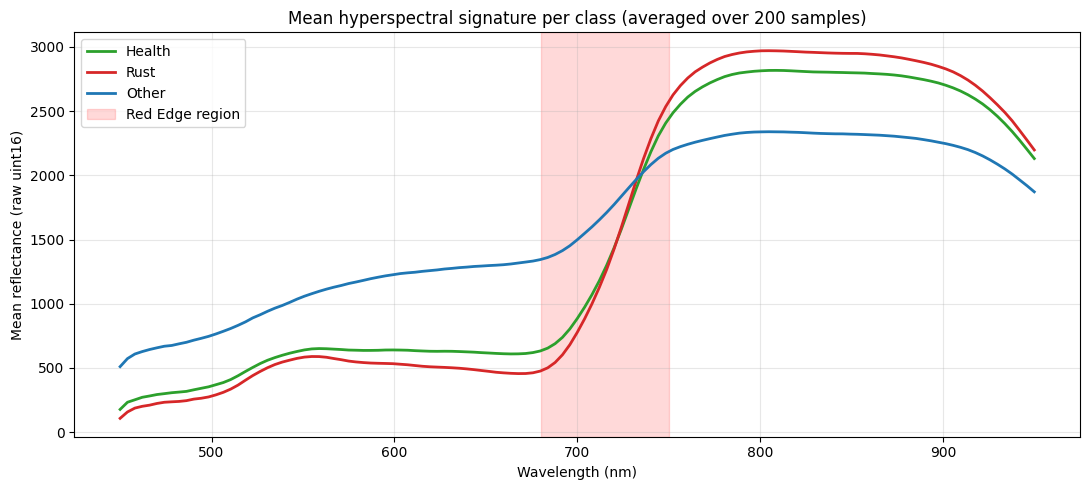

Saved: /kaggle/working/figures/fig2_hs_signatures.png

Top 5 most discriminative bands for Rust vs Health:
  band  56  (676 nm)  diff = -157.5
  band  85  (793 nm)  diff = +157.0
  band  81  (777 nm)  diff = +156.7
  band  57  (680 nm)  diff = -156.6
  band  82  (781 nm)  diff = +156.5


In [7]:
wavelengths = np.linspace(450, 950, HS_BANDS)

mean_signatures = {}
for cls in CLASS_NAMES:
    files = train_df[train_df['class_name'] == cls]['hs_path'].tolist()
    accum = np.zeros(HS_BANDS, dtype=np.float64)
    kept = 0
    for f in tqdm(files, desc=cls, leave=False):
        cube = load_tif(f).astype(np.float32)
        if cube.shape[0] < HS_BANDS:
            continue
        cube = cube[:HS_BANDS]
        accum += cube.mean(axis=(1, 2))
        kept += 1
    mean_signatures[cls] = accum / kept

fig, ax = plt.subplots(figsize=(11, 5))
colors = {'Health': '#2ca02c', 'Rust': '#d62728', 'Other': '#1f77b4'}
for cls in CLASS_NAMES:
    ax.plot(wavelengths, mean_signatures[cls], label=cls, linewidth=2, color=colors[cls])
ax.axvspan(680, 750, alpha=0.15, color='red', label='Red Edge region')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Mean reflectance (raw uint16)')
ax.set_title('Mean hyperspectral signature per class (averaged over 200 samples)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_hs_signatures.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/fig2_hs_signatures.png')

diff_rust = mean_signatures['Rust'] - mean_signatures['Health']
top5 = np.argsort(np.abs(diff_rust))[-5:][::-1]
print('\nTop 5 most discriminative bands for Rust vs Health:')
for idx in top5:
    print(f'  band {idx:3d}  ({wavelengths[idx]:.0f} nm)  diff = {diff_rust[idx]:+.1f}')

## 7. Per-Band Normalization Statistics

RGB channels use standard ImageNet normalization since we're using a pretrained backbone. For MS and HS there are no pretrained statistics available, so we compute per-band mean and standard deviation on the training set and use these for z-score normalization.


In [8]:
print('Computing HS per-band mean/std on training set...')
hs_sums = np.zeros(HS_BANDS, dtype=np.float64)
hs_sq_sums = np.zeros(HS_BANDS, dtype=np.float64)
hs_count = 0
for p in tqdm(train_df['hs_path'].tolist()):
    with rasterio.open(p) as src:
        hs = src.read().astype(np.float32)
    hs = hs[:HS_BANDS]
    hs_sums += hs.sum(axis=(1, 2))
    hs_sq_sums += (hs ** 2).sum(axis=(1, 2))
    hs_count += hs.shape[1] * hs.shape[2]
HS_MEAN = hs_sums / hs_count
HS_STD  = np.sqrt(np.maximum(hs_sq_sums / hs_count - HS_MEAN ** 2, 0))
print(f'HS_MEAN range: [{HS_MEAN.min():.1f}, {HS_MEAN.max():.1f}]')
print(f'HS_STD range:  [{HS_STD.min():.1f}, {HS_STD.max():.1f}]')

print('\nComputing MS per-band mean/std on training set...')
ms_sums = np.zeros(5, dtype=np.float64)
ms_sq_sums = np.zeros(5, dtype=np.float64)
ms_count = 0
for p in tqdm(train_df['ms_path'].tolist()):
    with rasterio.open(p) as src:
        ms = src.read().astype(np.float32)
    ms_sums += ms.sum(axis=(1, 2))
    ms_sq_sums += (ms ** 2).sum(axis=(1, 2))
    ms_count += ms.shape[1] * ms.shape[2]
MS_MEAN = ms_sums / ms_count
MS_STD  = np.sqrt(np.maximum(ms_sq_sums / ms_count - MS_MEAN ** 2, 0))
print(f'MS_MEAN: {MS_MEAN.round(1)}')
print(f'MS_STD:  {MS_STD.round(1)}')

Computing HS per-band mean/std on training set...


100%|██████████| 600/600 [00:05<00:00, 116.23it/s]


HS_MEAN range: [264.6, 2708.8]
HS_STD range:  [330.0, 1119.3]

Computing MS per-band mean/std on training set...


100%|██████████| 600/600 [00:07<00:00, 84.47it/s]

MS_MEAN: [ 412.8  760.9  795.4 2184.5 2693.5]
MS_STD:  [ 377.8  469.2  665.5  858.2 1127.9]


## 8. Dataset Class

The dataset loads all three modalities and returns:
- `rgb_ms`: an (8, 224, 224) tensor — RGB (ImageNet-normalized) concatenated with MS (z-score normalized, upsampled to 224×224)
- `hs`: a (125, 32, 32) tensor — HS z-score normalized, kept at native resolution

For augmentation, flips and 90° rotations are applied to all modalities at once to preserve spatial alignment. Color jitter is applied only to RGB, since color is part of the disease signal and we don't want to corrupt it.


In [9]:
class WheatTriModalDataset(Dataset):


    def __init__(self, df, train: bool):
        self.df = df.reset_index(drop=True)
        self.train = train
        self.rgb_aug = T.ColorJitter(brightness=0.1, contrast=0.1,
                                     saturation=0.05, hue=0.02) if train else None

    def __len__(self):
        return len(self.df)

    def _load_rgb(self, path):
        img = Image.open(path).convert('RGB')
        if self.train and self.rgb_aug is not None:
            img = self.rgb_aug(img)
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        arr = np.array(img).astype(np.float32) / 255.0
        arr = (arr - np.array(IMAGENET_MEAN)) / np.array(IMAGENET_STD)
        return torch.from_numpy(arr.transpose(2, 0, 1)).float()

    def _load_ms(self, path):
        with rasterio.open(path) as src:
            ms = src.read().astype(np.float32)
        ms = (ms - MS_MEAN[:, None, None]) / (MS_STD[:, None, None] + 1e-6)
        ms_t = torch.from_numpy(ms).unsqueeze(0)
        ms_t = F.interpolate(ms_t, size=(IMG_SIZE, IMG_SIZE),
                             mode='bilinear', align_corners=False)
        return ms_t.squeeze(0).float()

    def _load_hs(self, path):
        with rasterio.open(path) as src:
            hs = src.read().astype(np.float32)
        hs = hs[:HS_BANDS]
        hs = (hs - HS_MEAN[:, None, None]) / (HS_STD[:, None, None] + 1e-6)
        return torch.from_numpy(hs).float()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rgb = self._load_rgb(row['rgb_path'])
        ms  = self._load_ms(row['ms_path'])
        hs  = self._load_hs(row['hs_path'])

        rgb_ms = torch.cat([rgb, ms], dim=0)

        if self.train:
            if random.random() < 0.5:
                rgb_ms = torch.flip(rgb_ms, dims=[2])
                hs = torch.flip(hs, dims=[2])
            if random.random() < 0.5:
                rgb_ms = torch.flip(rgb_ms, dims=[1])
                hs = torch.flip(hs, dims=[1])
            k = random.randint(0, 3)
            if k > 0:
                rgb_ms = torch.rot90(rgb_ms, k=k, dims=[1, 2])
                hs = torch.rot90(hs, k=k, dims=[1, 2])

        label = torch.tensor(row['label'], dtype=torch.long)
        return {'rgb_ms': rgb_ms, 'hs': hs}, label


_ds = WheatTriModalDataset(train_df.head(4), train=False)
sample, _y = _ds[0]
print(f"rgb_ms tensor: shape {tuple(sample['rgb_ms'].shape)}, range [{sample['rgb_ms'].min():.2f}, {sample['rgb_ms'].max():.2f}]")
print(f"hs tensor:     shape {tuple(sample['hs'].shape)}, range [{sample['hs'].min():.2f}, {sample['hs'].max():.2f}]")
print(f"Label: {_y.item()} ({IDX_TO_CLASS[_y.item()]})")

rgb_ms tensor: shape (8, 224, 224), range [-2.12, 2.64]
hs tensor:     shape (125, 32, 32), range [-0.49, 2.19]
Label: 0 (Health)


## 9. Model Architecture

The main challenge with hyperspectral data is that 125 bands can't be fed directly into an ImageNet-pretrained convolutional layer. Instead of discarding bands or using PCA, we learn a compact spectral summary using 1×1 convolutions along the spectral axis.

**HSSpectralEncoder:** treats each pixel's 125-band spectrum independently and compresses it to 16 channels using two Conv1d layers (125 → 64 → 16). The result is upsampled from 32×32 to 224×224 to match the RGB and MS spatial resolution. This adds only ~10K parameters.

**TriModalModel:** stacks RGB+MS (8 ch) with the encoded HS (16 ch) to form a 24-channel input, then feeds it into ResNet50. The `timm` library handles the first-layer weight averaging to preserve the ImageNet prior on the RGB channels.


In [10]:
class HSSpectralEncoder(nn.Module):


    def __init__(self, in_bands=HS_BANDS, hidden=64, out_ch=HS_ENCODED_CH):
        super().__init__()
        self.spectral = nn.Sequential(
            nn.Conv1d(in_bands, hidden, kernel_size=1),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Conv1d(hidden, out_ch, kernel_size=1),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        B, C, H, W = x.shape
        x = x.reshape(B, C, H * W)
        x = self.spectral(x)
        x = x.reshape(B, -1, H, W)
        x = F.interpolate(x, size=(IMG_SIZE, IMG_SIZE),
                          mode='bilinear', align_corners=False)
        return x


class TriModalModel(nn.Module):


    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.hs_encoder = HSSpectralEncoder(in_bands=HS_BANDS,
                                            hidden=64,
                                            out_ch=HS_ENCODED_CH)
        self.backbone = timm.create_model(
            'resnet50',
            pretrained=True,
            num_classes=num_classes,
            in_chans=8 + HS_ENCODED_CH,
        )

    def forward(self, rgb_ms, hs):
        hs_feat = self.hs_encoder(hs)
        x = torch.cat([rgb_ms, hs_feat], dim=1)
        return self.backbone(x)


def build_model():
    return TriModalModel(num_classes=NUM_CLASSES)


_m = build_model().to(DEVICE)
_rgbms = torch.randn(2, 8, IMG_SIZE, IMG_SIZE).to(DEVICE)
_hs = torch.randn(2, HS_BANDS, 32, 32).to(DEVICE)
with torch.no_grad():
    _out = _m(_rgbms, _hs)
print(f'Model output shape: {tuple(_out.shape)} (should be [2, 3])')
n_params = sum(p.numel() for p in _m.parameters())
print(f'Trainable parameters: {n_params:,}')
del _m, _rgbms, _hs, _out
torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model output shape: (2, 3) (should be [2, 3])
Trainable parameters: 23,589,299


## 10. Training and Validation

Standard PyTorch training loop. We track both accuracy and macro-F1 and save the best checkpoint per fold based on macro-F1 on the held-out validation set.


In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch, y in loader:
        rgb_ms = batch['rgb_ms'].to(DEVICE, non_blocking=True)
        hs = batch['hs'].to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        logits = model(rgb_ms, hs)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    for batch, y in loader:
        rgb_ms = batch['rgb_ms'].to(DEVICE, non_blocking=True)
        hs = batch['hs'].to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(rgb_ms, hs)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_targets.extend(y.cpu().numpy())
    acc = (np.array(all_preds) == np.array(all_targets)).mean()
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    return total_loss / len(all_targets), acc, macro_f1, all_preds, all_targets

## 11. 5-Fold Stratified Cross-Validation

We train 5 models, each on a different 480/120 split. Training takes roughly 35 minutes on a Kaggle T4 GPU. Hyperparameters: 25 epochs, AdamW (lr=1e-4, weight decay=1e-4), cosine annealing LR, batch size 32, cross-entropy loss.


In [12]:
import time
import rasterio
from PIL import Image

row = train_df.iloc[0]

t0 = time.time()
img = Image.open(row['rgb_path']).convert('RGB')
print(f'RGB load:  {(time.time()-t0)*1000:.0f} ms')

t0 = time.time()
with rasterio.open(row['ms_path']) as src: ms = src.read()
print(f'MS load:   {(time.time()-t0)*1000:.0f} ms')

t0 = time.time()
with rasterio.open(row['hs_path']) as src: hs = src.read()
print(f'HS load:   {(time.time()-t0)*1000:.0f} ms')

print(f'\nEstimated time per epoch (~600 samples, batch=32):')
total_ms = ((time.time()-t0)*1000 + 5 + 10) * 600
print(f'  ~{total_ms/1000:.0f} seconds = ~{total_ms/60000:.1f} minutes')

RGB load:  3 ms
MS load:   14 ms
HS load:   10 ms

Estimated time per epoch (~600 samples, batch=32):
  ~15 seconds = ~0.3 minutes


In [13]:
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,utilization.gpu',
                        '--format=csv,noheader'], capture_output=True, text=True)
print(result.stdout)

Tesla T4, 15360 MiB, 0 %
Tesla T4, 15360 MiB, 0 %



In [14]:

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []
all_fold_preds = []
all_fold_targets = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, train_df['label'])):
    print(f'\n{"="*60}\nFOLD {fold + 1}/{N_FOLDS}\n{"="*60}')
    set_seed(SEED + fold)

    tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
    va_df = train_df.iloc[va_idx].reset_index(drop=True)

    tr_ds = WheatTriModalDataset(tr_df, train=True)
    va_ds = WheatTriModalDataset(va_df, train=False)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=4, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=4, pin_memory=True)

    model = build_model().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    best_f1, best_epoch = 0.0, 0

    for epoch in range(EPOCHS):
        tr_loss, tr_acc = train_one_epoch(model, tr_loader, optimizer, criterion)
        va_loss, va_acc, va_f1, _, _ = validate(model, va_loader, criterion)
        scheduler.step()

        flag = ' ★' if va_f1 > best_f1 else ''
        print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
              f'tr_loss {tr_loss:.3f} tr_acc {tr_acc:.3f} | '
              f'va_loss {va_loss:.3f} va_acc {va_acc:.3f} va_f1 {va_f1:.3f}{flag}')

        if va_f1 > best_f1:
            best_f1 = va_f1
            best_epoch = epoch
            torch.save(model.state_dict(), CKPT_DIR / f'fold{fold}_best.pt')

    model.load_state_dict(torch.load(CKPT_DIR / f'fold{fold}_best.pt'))
    _, va_acc, va_f1, preds, targets = validate(model, va_loader, criterion)
    print(f'\n>>> Fold {fold+1} BEST: epoch {best_epoch+1}, '
          f'val_acc={va_acc:.4f}, val_f1={va_f1:.4f}')
    print(classification_report(targets, preds, target_names=CLASS_NAMES, digits=3))

    fold_results.append({
        'fold': fold + 1,
        'best_epoch': best_epoch + 1,
        'val_acc': va_acc,
        'val_f1': va_f1,
    })
    all_fold_preds.extend(preds)
    all_fold_targets.extend(targets)

    del model
    torch.cuda.empty_cache()

results_df = pd.DataFrame(fold_results)
print('\n' + '='*60)
print('5-FOLD CROSS-VALIDATION SUMMARY')
print('='*60)
print(results_df.to_string(index=False))
print(f'\nMean accuracy: {results_df.val_acc.mean():.4f} ± {results_df.val_acc.std():.4f}')
print(f'Mean macro-F1: {results_df.val_f1.mean():.4f} ± {results_df.val_f1.std():.4f}')

results_df.to_csv(OUTPUT_DIR / 'cv_results.csv', index=False)
print(f'\nSaved: cv_results.csv')


FOLD 1/5
Epoch 01/25 | tr_loss 1.092 tr_acc 0.377 | va_loss 1.096 va_acc 0.325 va_f1 0.263 ★
Epoch 02/25 | tr_loss 1.062 tr_acc 0.481 | va_loss 1.066 va_acc 0.567 va_f1 0.567 ★
Epoch 03/25 | tr_loss 1.028 tr_acc 0.565 | va_loss 1.023 va_acc 0.592 va_f1 0.545
Epoch 04/25 | tr_loss 0.989 tr_acc 0.590 | va_loss 0.982 va_acc 0.600 va_f1 0.533
Epoch 05/25 | tr_loss 0.949 tr_acc 0.594 | va_loss 0.901 va_acc 0.617 va_f1 0.529
Epoch 06/25 | tr_loss 0.907 tr_acc 0.588 | va_loss 0.844 va_acc 0.617 va_f1 0.541
Epoch 07/25 | tr_loss 0.872 tr_acc 0.610 | va_loss 0.832 va_acc 0.642 va_f1 0.585 ★
Epoch 08/25 | tr_loss 0.854 tr_acc 0.604 | va_loss 0.798 va_acc 0.675 va_f1 0.619 ★
Epoch 09/25 | tr_loss 0.833 tr_acc 0.613 | va_loss 0.778 va_acc 0.667 va_f1 0.631 ★
Epoch 10/25 | tr_loss 0.815 tr_acc 0.629 | va_loss 0.776 va_acc 0.658 va_f1 0.612
Epoch 11/25 | tr_loss 0.784 tr_acc 0.637 | va_loss 0.754 va_acc 0.692 va_f1 0.651 ★
Epoch 12/25 | tr_loss 0.779 tr_acc 0.633 | va_loss 0.752 va_acc 0.700 va_f1 

## 11b. EfficientNet-B0 Baseline (RGB only)

To compare against a second architecturally distinct baseline, we train EfficientNet-B0 on RGB-only input using the exact same training recipe as the ResNet50 runs. The model uses only the first 3 channels of the `rgb_ms` tensor, so the dataset and splits are byte-for-byte identical.

EfficientNet-B0 (~5.3M parameters) is a useful second reference point because it uses a fundamentally different design from ResNet50 — inverted-residual mobile blocks with compound scaling — and is naturally less prone to overfitting on a 600-sample dataset.


In [15]:

class EffNetRGBBaseline(nn.Module):
    """EfficientNet-B0 (ImageNet-pretrained) on RGB-only input (3 channels).

    Takes the same 8-channel rgb_ms tensor the dataset produces and uses only
    the first 3 (RGB) channels, so the data pipeline is identical to Model A.
    """

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            num_classes=num_classes,
            in_chans=3,
        )

    def forward(self, rgb_ms, hs=None):
        rgb = rgb_ms[:, :3, :, :]
        return self.backbone(rgb)


def build_effnet_model():
    return EffNetRGBBaseline(num_classes=NUM_CLASSES)


_m = build_effnet_model().to(DEVICE)
_rgbms = torch.randn(2, 8, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    _out = _m(_rgbms)
print(f'EfficientNet-B0 output shape: {tuple(_out.shape)} (should be [2, 3])')
n_params = sum(p.numel() for p in _m.parameters())
print(f'Trainable parameters: {n_params:,}')
del _m, _rgbms, _out
torch.cuda.empty_cache()

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet-B0 output shape: (2, 3) (should be [2, 3])
Trainable parameters: 4,011,391


In [16]:

skf_eff = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
eff_fold_results = []
eff_oof_preds = []
eff_oof_targets = []

for fold, (tr_idx, va_idx) in enumerate(skf_eff.split(train_df, train_df['label'])):
    print(f'\n{"="*60}\n[EfficientNet-B0] FOLD {fold + 1}/{N_FOLDS}\n{"="*60}')
    set_seed(SEED + fold)

    tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
    va_df = train_df.iloc[va_idx].reset_index(drop=True)

    tr_ds = WheatTriModalDataset(tr_df, train=True)
    va_ds = WheatTriModalDataset(va_df, train=False)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)

    model = build_effnet_model().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    best_f1, best_epoch = 0.0, 0

    for epoch in range(EPOCHS):
        tr_loss, tr_acc = train_one_epoch(model, tr_loader, optimizer, criterion)
        va_loss, va_acc, va_f1, _, _ = validate(model, va_loader, criterion)
        scheduler.step()

        flag = ' *' if va_f1 > best_f1 else ''
        print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
              f'tr_loss {tr_loss:.3f} tr_acc {tr_acc:.3f} | '
              f'va_loss {va_loss:.3f} va_acc {va_acc:.3f} va_f1 {va_f1:.3f}{flag}')

        if va_f1 > best_f1:
            best_f1 = va_f1
            best_epoch = epoch
            torch.save(model.state_dict(), CKPT_DIR / f'effnet_fold{fold}_best.pt')

    model.load_state_dict(torch.load(CKPT_DIR / f'effnet_fold{fold}_best.pt'))
    _, va_acc, va_f1, preds, targets = validate(model, va_loader, criterion)
    print(f'\n>>> [EfficientNet-B0] Fold {fold+1} BEST: epoch {best_epoch+1}, '
          f'val_acc={va_acc:.4f}, val_f1={va_f1:.4f}')
    print(classification_report(targets, preds, target_names=CLASS_NAMES, digits=3))

    eff_fold_results.append({
        'fold': fold + 1,
        'best_epoch': best_epoch + 1,
        'val_acc': va_acc,
        'val_f1': va_f1,
    })
    eff_oof_preds.extend(preds)
    eff_oof_targets.extend(targets)

    del model
    torch.cuda.empty_cache()

eff_results_df = pd.DataFrame(eff_fold_results)
print('\n' + '='*60)
print('[EfficientNet-B0] 5-FOLD CROSS-VALIDATION SUMMARY')
print('='*60)
print(eff_results_df.to_string(index=False))
print(f'\nMean accuracy: {eff_results_df.val_acc.mean():.4f} +/- {eff_results_df.val_acc.std():.4f}')
print(f'Mean macro-F1: {eff_results_df.val_f1.mean():.4f} +/- {eff_results_df.val_f1.std():.4f}')

eff_results_df.to_csv(OUTPUT_DIR / 'cv_results_effnet.csv', index=False)
print('\nSaved: cv_results_effnet.csv')


[EfficientNet-B0] FOLD 1/5
Epoch 01/25 | tr_loss 3.005 tr_acc 0.383 | va_loss 2.743 va_acc 0.400 va_f1 0.360 *
Epoch 02/25 | tr_loss 1.866 tr_acc 0.519 | va_loss 2.144 va_acc 0.475 va_f1 0.480 *
Epoch 03/25 | tr_loss 1.271 tr_acc 0.590 | va_loss 2.041 va_acc 0.533 va_f1 0.527 *
Epoch 04/25 | tr_loss 1.152 tr_acc 0.635 | va_loss 1.987 va_acc 0.550 va_f1 0.534 *
Epoch 05/25 | tr_loss 0.972 tr_acc 0.677 | va_loss 1.915 va_acc 0.558 va_f1 0.553 *
Epoch 06/25 | tr_loss 0.713 tr_acc 0.773 | va_loss 1.824 va_acc 0.608 va_f1 0.604 *
Epoch 07/25 | tr_loss 0.777 tr_acc 0.731 | va_loss 1.802 va_acc 0.608 va_f1 0.603
Epoch 08/25 | tr_loss 0.650 tr_acc 0.760 | va_loss 1.738 va_acc 0.617 va_f1 0.617 *
Epoch 09/25 | tr_loss 0.641 tr_acc 0.762 | va_loss 1.766 va_acc 0.617 va_f1 0.610
Epoch 10/25 | tr_loss 0.456 tr_acc 0.806 | va_loss 1.754 va_acc 0.625 va_f1 0.615
Epoch 11/25 | tr_loss 0.471 tr_acc 0.827 | va_loss 1.830 va_acc 0.558 va_f1 0.553
Epoch 12/25 | tr_loss 0.405 tr_acc 0.856 | va_loss 1.774

In [17]:

RESNET50_RGB_ACC = 0.598   # Model A (RGB only), report Table 1
RESNET50_RGB_F1  = 0.566

print('='*64)
print('ARCHITECTURE BASELINE COMPARISON (RGB-only, identical recipe)')
print('='*64)
print(f'{"Model":<24}{"Backbone params":<18}{"CV Acc":<10}{"CV Macro-F1":<12}')
print('-'*64)
print(f'{"Baseline 1 (ResNet50)":<24}{"~25.0M":<18}{RESNET50_RGB_ACC:<10.3f}{RESNET50_RGB_F1:<12.3f}')
print(f'{"Baseline 2 (EffNet-B0)":<24}{"~5.3M":<18}'
      f'{eff_results_df.val_acc.mean():<10.3f}{eff_results_df.val_f1.mean():<12.3f}')
print('='*64)
print('\nBoth baselines use RGB only. The tri-modal model (RGB+MS+HS) with the')
print('learned HS spectral encoder is the proposed method that improves on both.')

ARCHITECTURE BASELINE COMPARISON (RGB-only, identical recipe)
Model                   Backbone params   CV Acc    CV Macro-F1 
----------------------------------------------------------------
Baseline 1 (ResNet50)   ~25.0M            0.598     0.566       
Baseline 2 (EffNet-B0)  ~5.3M             0.623     0.624       

Both baselines use RGB only. The tri-modal model (RGB+MS+HS) with the
learned HS spectral encoder is the proposed method that improves on both.


## 12. Out-of-Fold Evaluation

We aggregate predictions across all 5 folds so that every training sample has been predicted exactly once by a model that never saw it during training. This gives the most honest view of per-class performance.


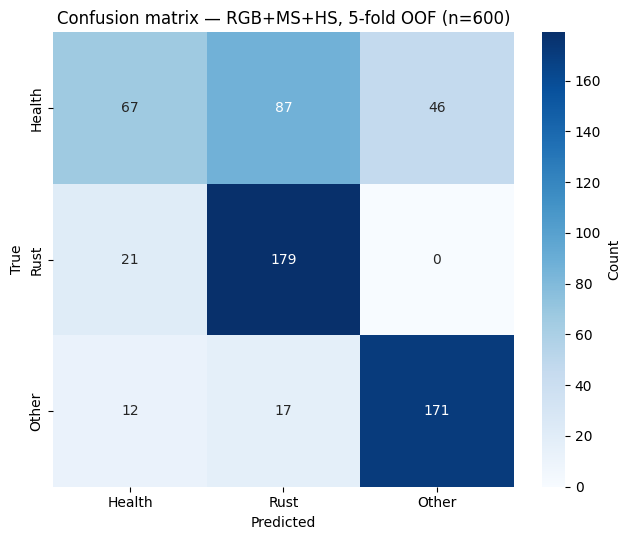

Saved: /kaggle/working/figures/fig3_confusion_matrix.png

Out-of-fold classification report:
              precision    recall  f1-score   support

      Health      0.670     0.335     0.447       200
        Rust      0.633     0.895     0.741       200
       Other      0.788     0.855     0.820       200

    accuracy                          0.695       600
   macro avg      0.697     0.695     0.669       600
weighted avg      0.697     0.695     0.669       600



In [18]:
cm = confusion_matrix(all_fold_targets, all_fold_preds, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion matrix — RGB+MS+HS, 5-fold OOF (n={len(all_fold_targets)})')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/fig3_confusion_matrix.png')

print('\nOut-of-fold classification report:')
print(classification_report(all_fold_targets, all_fold_preds, target_names=CLASS_NAMES, digits=3))

## 13. Kaggle Submission — 5-Fold Ensemble

We predict on the 300 validation samples using all 5 fold models and average their softmax probabilities before taking the argmax. On a small dataset like this, ensembling typically gives a 1–2 pp improvement over any single fold.


In [19]:
val_rgb_dir = DATA_ROOT / 'val' / 'RGB'
val_records = [{'rgb_path': str(fp),
                'ms_path':  str(DATA_ROOT / 'val' / 'MS' / f'{fp.stem}.tif'),
                'hs_path':  str(DATA_ROOT / 'val' / 'HS' / f'{fp.stem}.tif'),
                'filename': fp.name}
               for fp in sorted(val_rgb_dir.iterdir())]
val_df = pd.DataFrame(val_records)
val_df['label'] = 0
print(f'Validation samples: {len(val_df)}')

val_ds = WheatTriModalDataset(val_df, train=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

all_fold_probs = []
for fold in range(N_FOLDS):
    model = build_model().to(DEVICE)
    model.load_state_dict(torch.load(CKPT_DIR / f'fold{fold}_best.pt'))
    model.eval()
    fold_probs = []
    with torch.no_grad():
        for batch, _ in val_loader:
            rgb_ms = batch['rgb_ms'].to(DEVICE)
            hs = batch['hs'].to(DEVICE)
            probs = F.softmax(model(rgb_ms, hs), dim=1).cpu().numpy()
            fold_probs.append(probs)
    all_fold_probs.append(np.concatenate(fold_probs, axis=0))
    del model
    torch.cuda.empty_cache()

mean_probs = np.mean(all_fold_probs, axis=0)
pred_labels = mean_probs.argmax(axis=1)

submission = pd.DataFrame({
    'Id': [fn.replace('.png', '.tif') for fn in val_df['filename']],
    'Category': [IDX_TO_CLASS[p] for p in pred_labels],
})
submission.to_csv(OUTPUT_DIR / 'submission.csv', index=False)
print(f'\nFirst 5 predictions:')
print(submission.head())
print(f'\nPredicted class distribution:')
print(submission['Category'].value_counts())
print(f'\nSaved: {OUTPUT_DIR}/submission.csv ({len(submission)} rows)')

Validation samples: 300

First 5 predictions:
                 Id Category
0  val_000a83c1.tif   Health
1  val_00a704b1.tif    Other
2  val_01dde030.tif    Other
3  val_024df365.tif     Rust
4  val_02afcb0e.tif     Rust

Predicted class distribution:
Category
Rust      148
Other     101
Health     51
Name: count, dtype: int64

Saved: /kaggle/working/submission.csv (300 rows)


## 14. Per-Fold Performance Chart


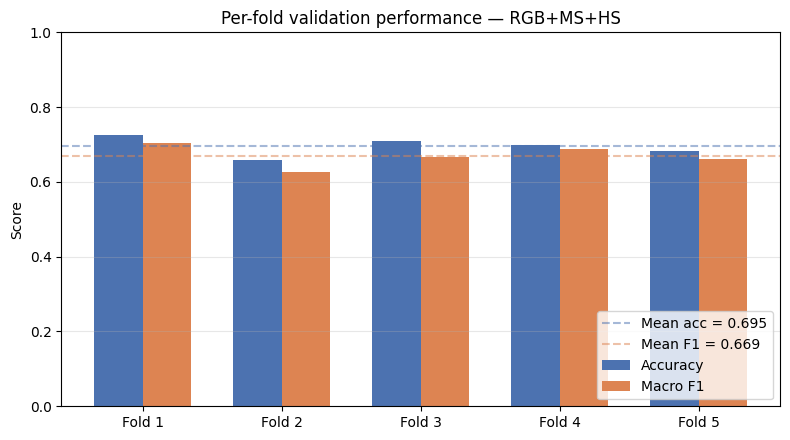

Saved: /kaggle/working/figures/fig4_per_fold_results.png


In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(N_FOLDS)
w = 0.35
ax.bar(x - w/2, results_df['val_acc'], w, label='Accuracy', color='#4c72b0')
ax.bar(x + w/2, results_df['val_f1'],  w, label='Macro F1', color='#dd8452')
ax.axhline(results_df.val_acc.mean(), color='#4c72b0', ls='--', alpha=0.5,
           label=f'Mean acc = {results_df.val_acc.mean():.3f}')
ax.axhline(results_df.val_f1.mean(), color='#dd8452', ls='--', alpha=0.5,
           label=f'Mean F1 = {results_df.val_f1.mean():.3f}')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in x])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Per-fold validation performance — RGB+MS+HS')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_per_fold_results.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}/fig4_per_fold_results.png')

## 15. Results Summary


In [21]:
print('='*60)
print('FINAL RESULTS — Tri-Modal Model (RGB + MS + HS)')
print('='*60)
print()
print('Method:     ResNet50 (ImageNet-pretrained) with learned 1D HS spectral encoder')
print('            24-channel input (3 RGB + 5 MS + 16 HS-encoded)')
print(f'Training:   {EPOCHS} epochs, AdamW (lr={LR}, wd={WEIGHT_DECAY}), Cosine LR')
print('Inputs:     RGB at 224x224 (ImageNet norm); MS upsampled to 224x224 (z-score);')
print('            HS at native 32x32 (z-score), upsampled to 224x224 after spectral encoder')
print('Train aug:  flips + 90° rotations (all modalities) + light color jitter (RGB only)')
print('Test:       no augmentation; 5-fold soft-vote ensemble for Kaggle submission')
print()
print('Per-fold validation metrics:')
print(results_df.to_string(index=False))
print()
print(f'Cross-validation mean:')
print(f'  Accuracy:  {results_df.val_acc.mean():.4f} ± {results_df.val_acc.std():.4f}')
print(f'  Macro F1:  {results_df.val_f1.mean():.4f} ± {results_df.val_f1.std():.4f}')
print()
print('Out-of-fold per-class metrics:')
print(classification_report(all_fold_targets, all_fold_preds, target_names=CLASS_NAMES, digits=3))
print()
print('Files saved to /kaggle/working/:')
for f in sorted(OUTPUT_DIR.glob('*')):
    if f.is_file():
        print(f'  {f.name}')
for f in sorted(FIG_DIR.glob('*')):
    print(f'  figures/{f.name}')

FINAL RESULTS — Tri-Modal Model (RGB + MS + HS)

Method:     ResNet50 (ImageNet-pretrained) with learned 1D HS spectral encoder
            24-channel input (3 RGB + 5 MS + 16 HS-encoded)
Training:   25 epochs, AdamW (lr=0.0001, wd=0.0001), Cosine LR
Inputs:     RGB at 224x224 (ImageNet norm); MS upsampled to 224x224 (z-score);
            HS at native 32x32 (z-score), upsampled to 224x224 after spectral encoder
Train aug:  flips + 90° rotations (all modalities) + light color jitter (RGB only)
Test:       no augmentation; 5-fold soft-vote ensemble for Kaggle submission

Per-fold validation metrics:
 fold  best_epoch  val_acc   val_f1
    1          21 0.725000 0.704113
    2          23 0.658333 0.625311
    3          18 0.708333 0.667438
    4          14 0.700000 0.688277
    5          13 0.683333 0.660558

Cross-validation mean:
  Accuracy:  0.6950 ± 0.0254
  Macro F1:  0.6691 ± 0.0299

Out-of-fold per-class metrics:
              precision    recall  f1-score   support

      Hea